In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [3]:
# Comunas faltantes
listado_comunas = [
    "TOCOPILLA", 
    "JUAN FERNÁNDEZ", 
    "ISLA DE PASCUA", 
    "EL QUISCO", 
    "SAAVEDRA", 
    "ANCUD", 
    "PUQUELDÓN", 
    "QUINCHAO", 
    "GUAITECAS", 
    "TORTEL", 
    "RÍO VERDE", 
    "PORVENIR", 
    "COBQUECURA"
]

In [6]:
# Cargar dataset procesado
ruta_a_datos = "../data/interim/demanda_comunal_horaria_temperatura.parquet"
df = pd.read_parquet(ruta_a_datos, engine="pyarrow")

# Filtrar datos de acuerdo a las comunas faltantes
df_faltantes = df[df["comuna"].isin(listado_comunas)].copy()

# Asegurar fecha y hora
df_faltantes["fecha_hora"] = pd.to_datetime(df_faltantes["fecha_hora"])

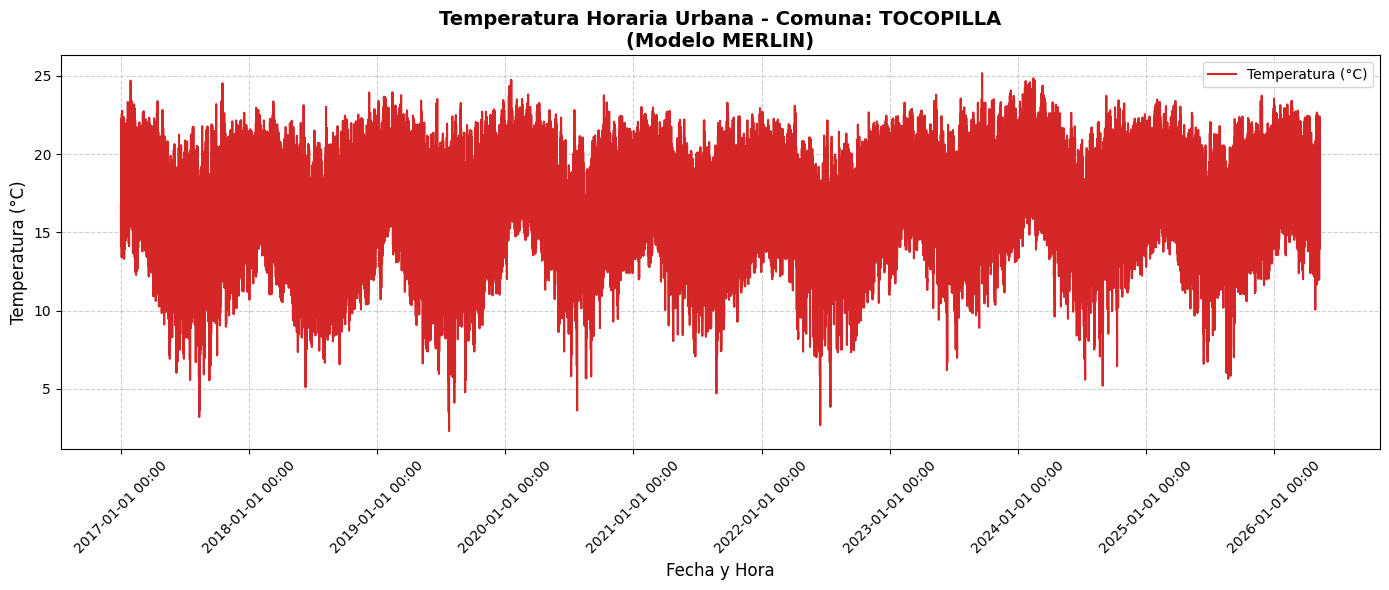

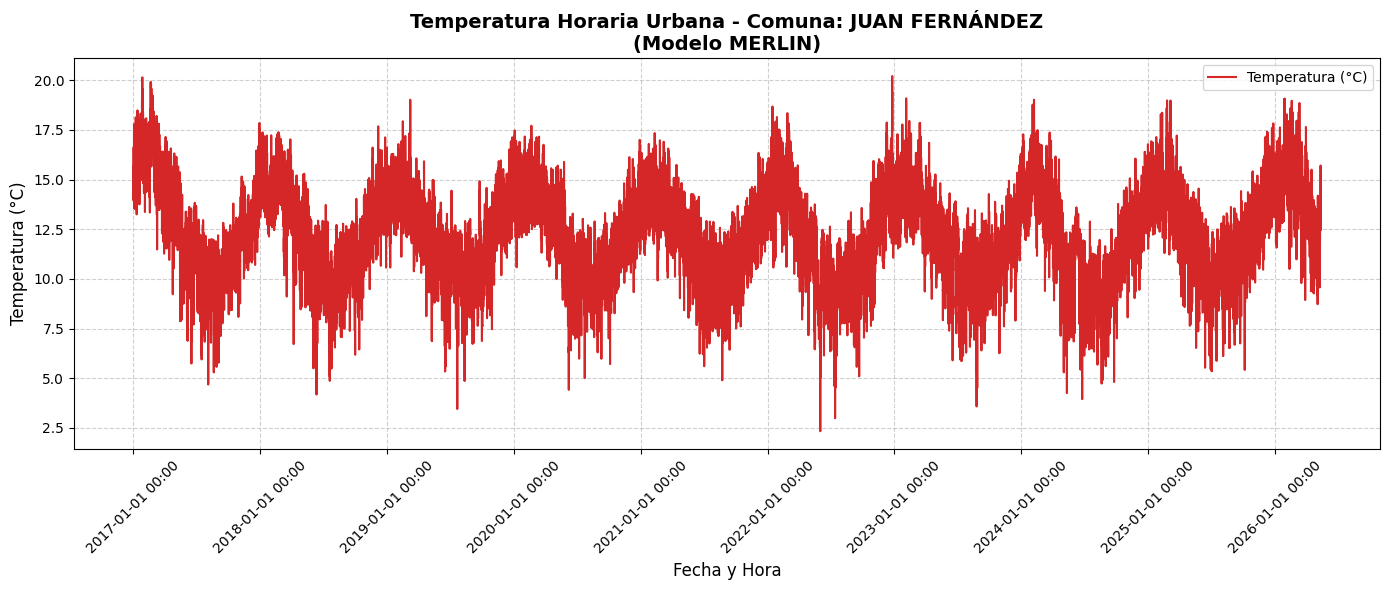

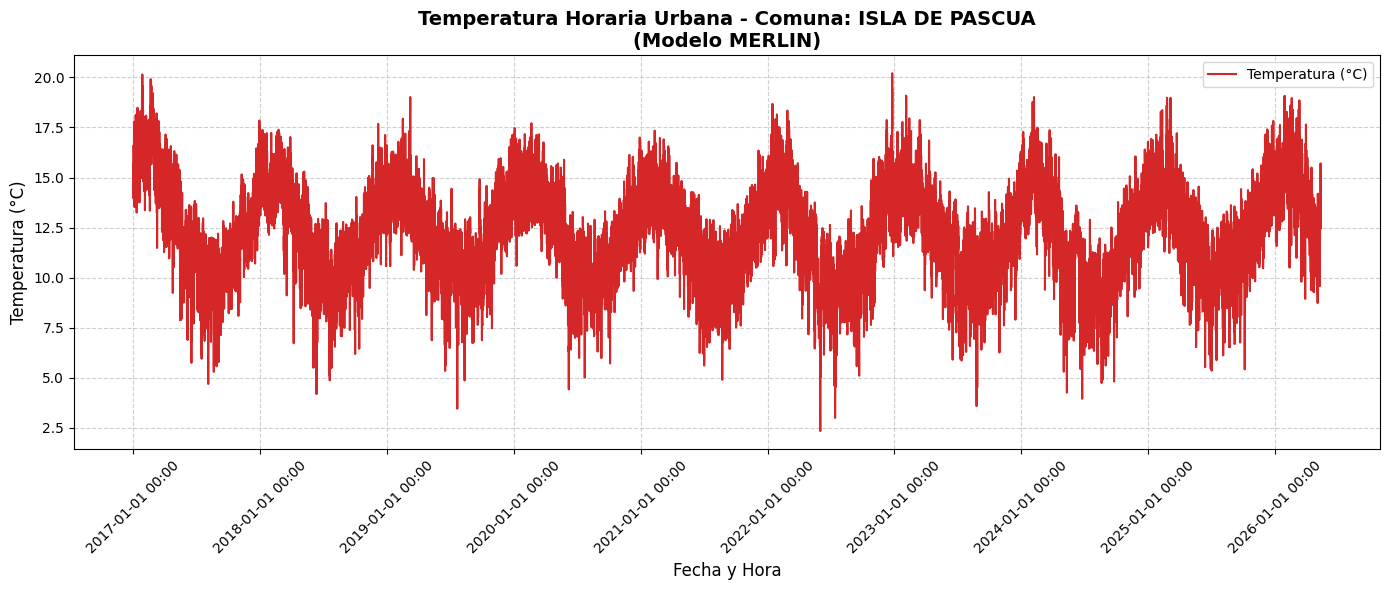

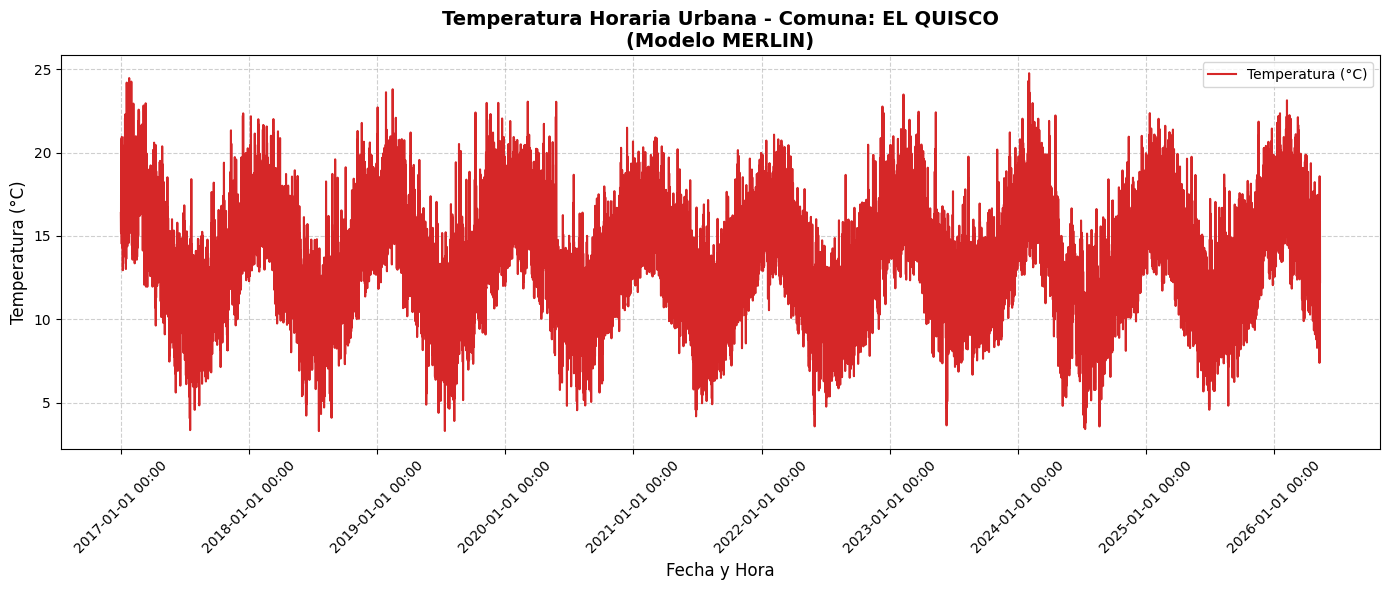

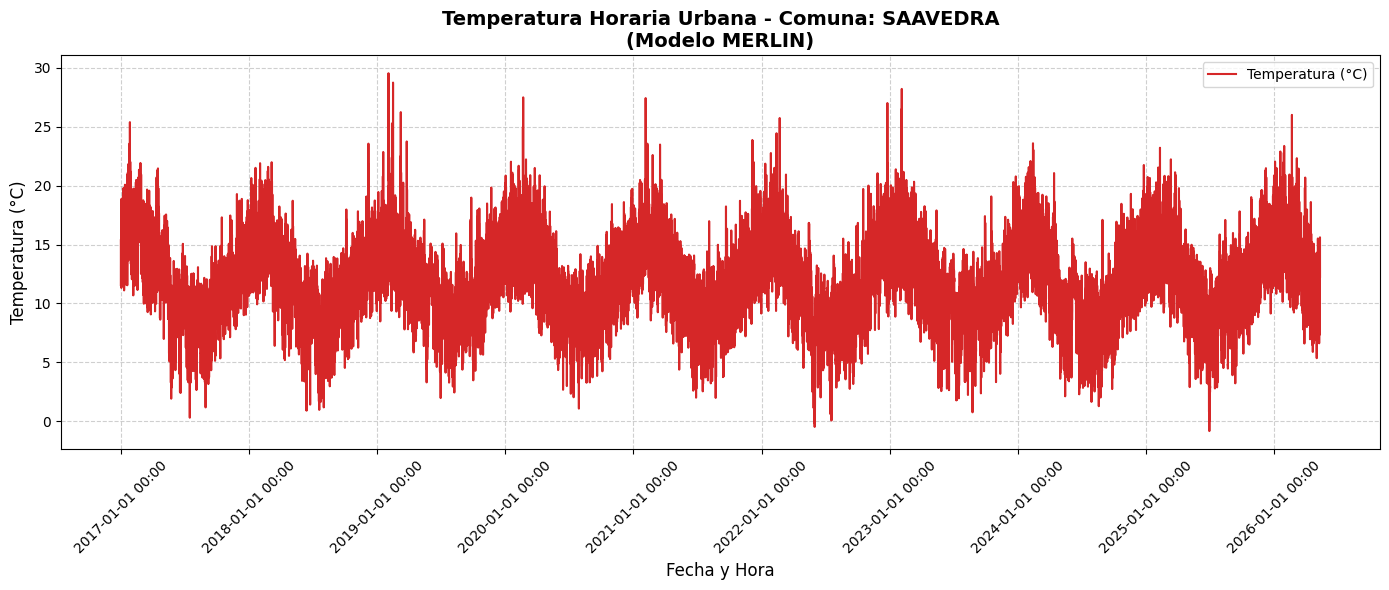

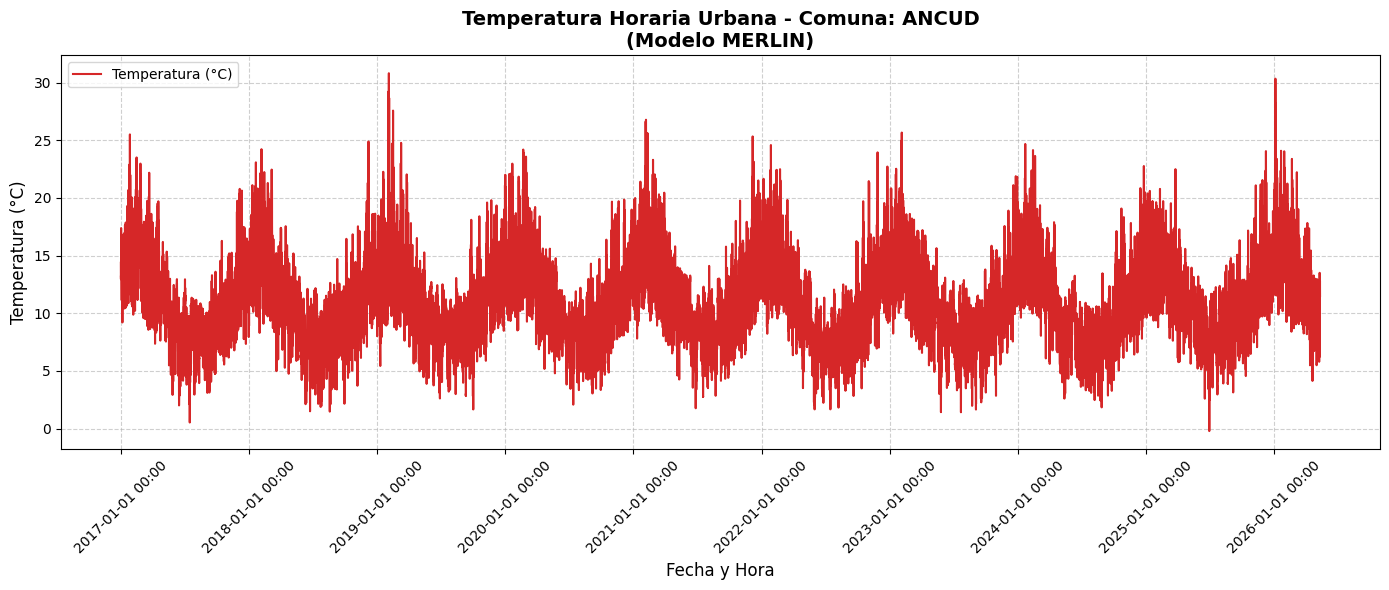

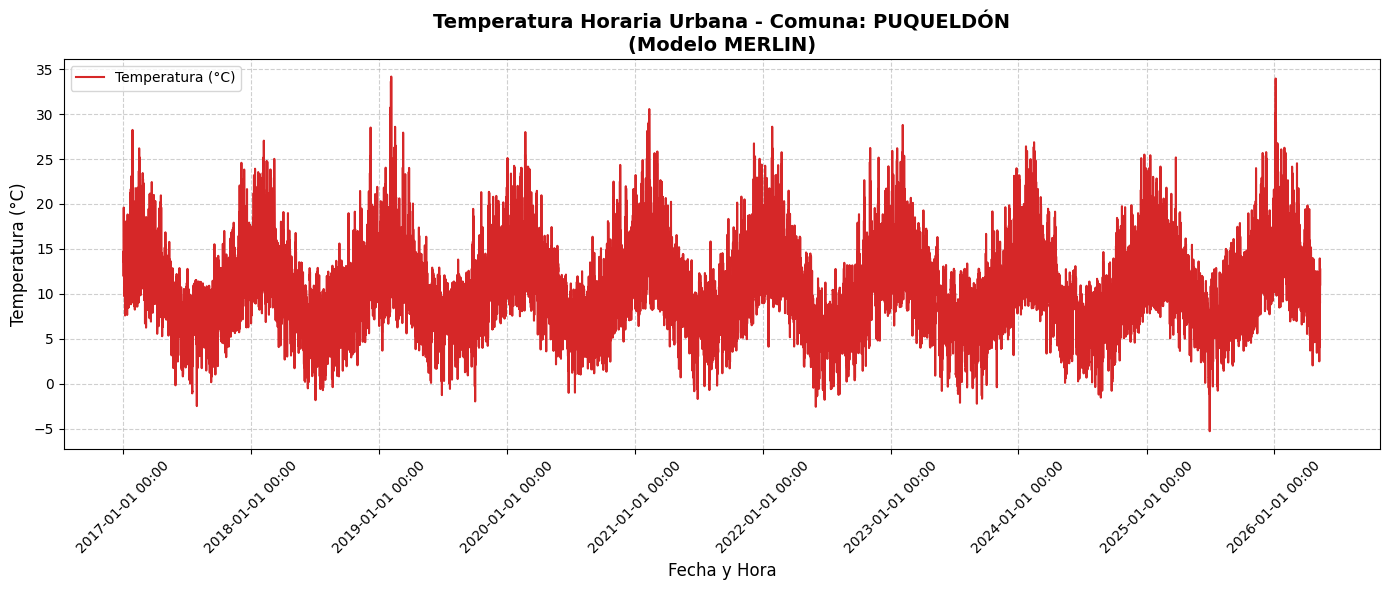

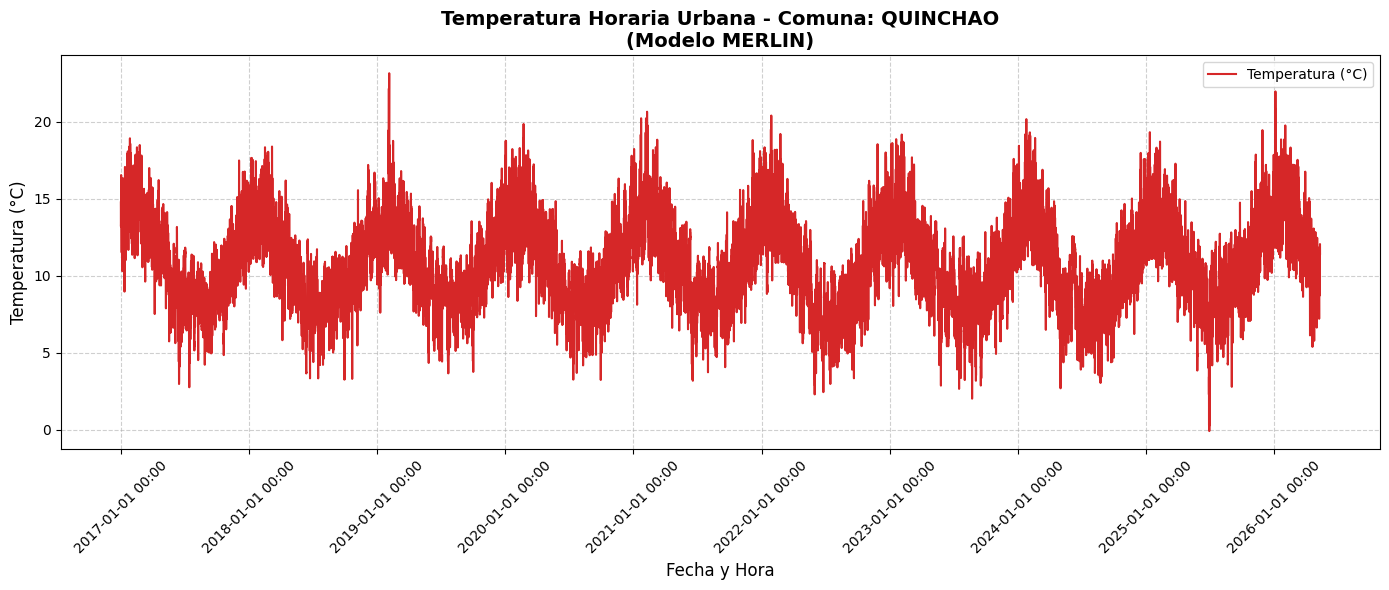

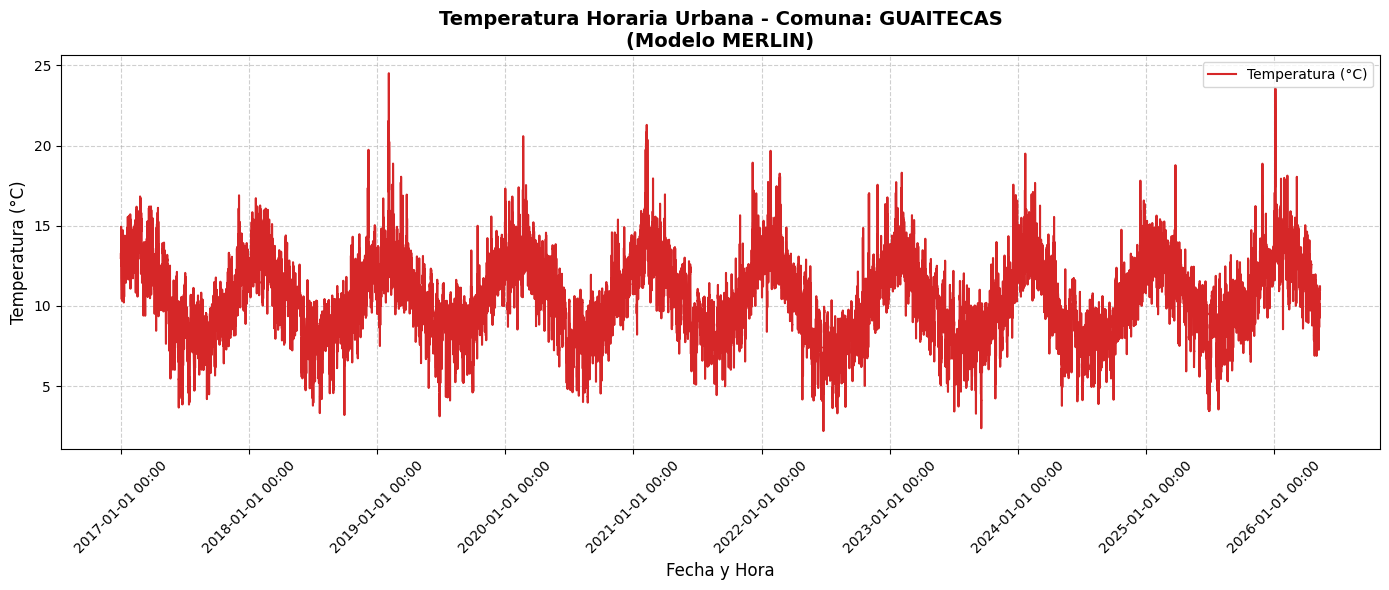

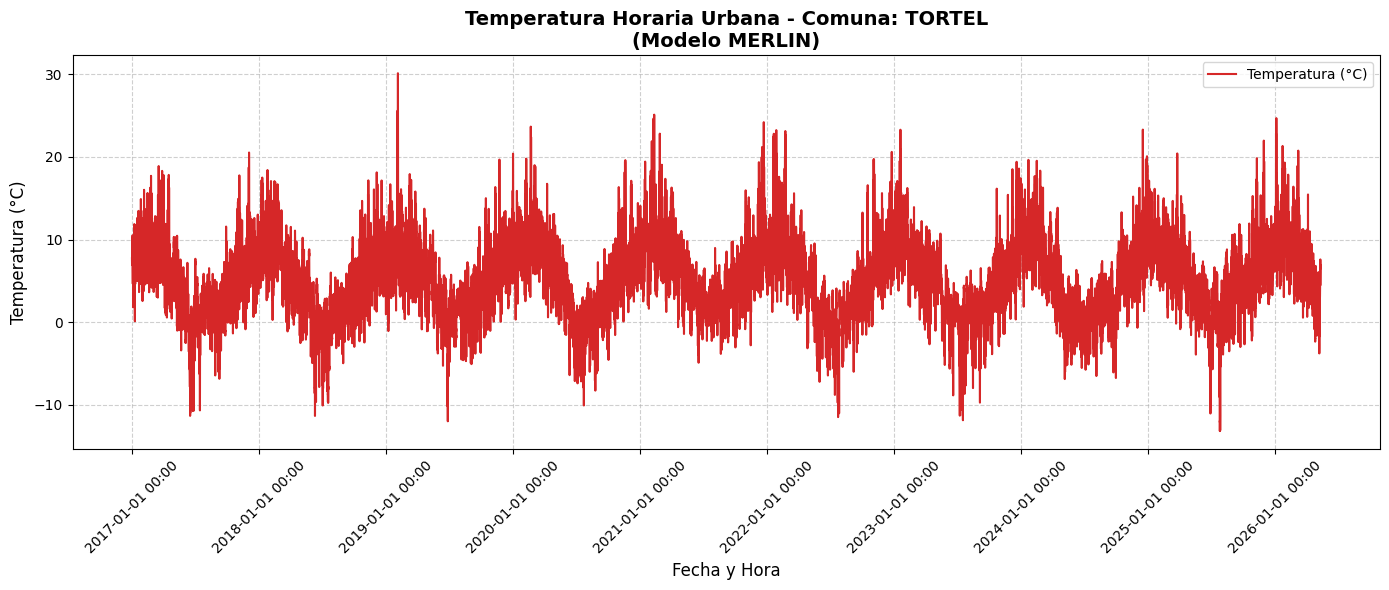

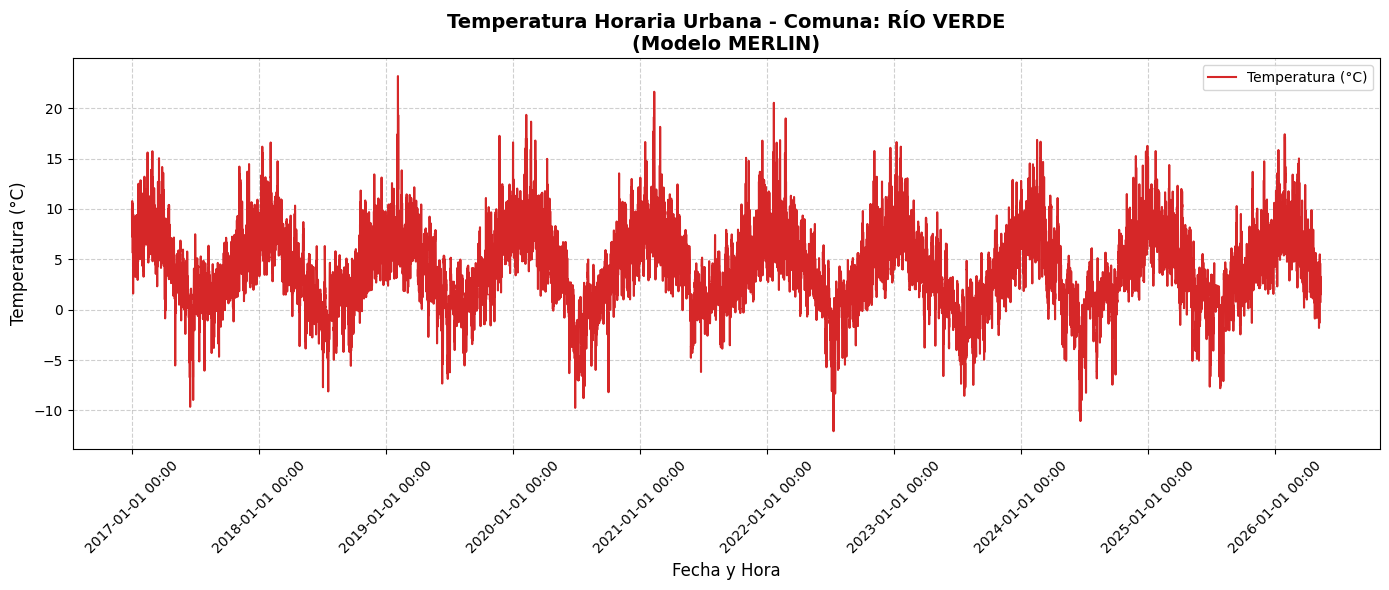

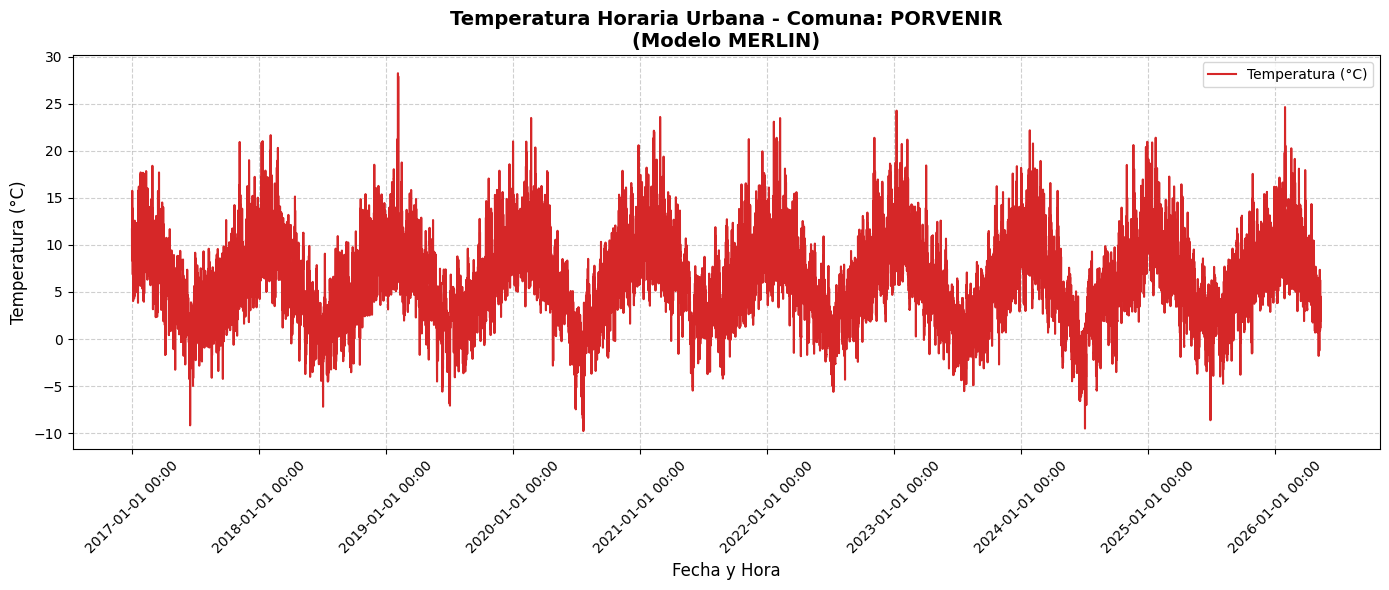

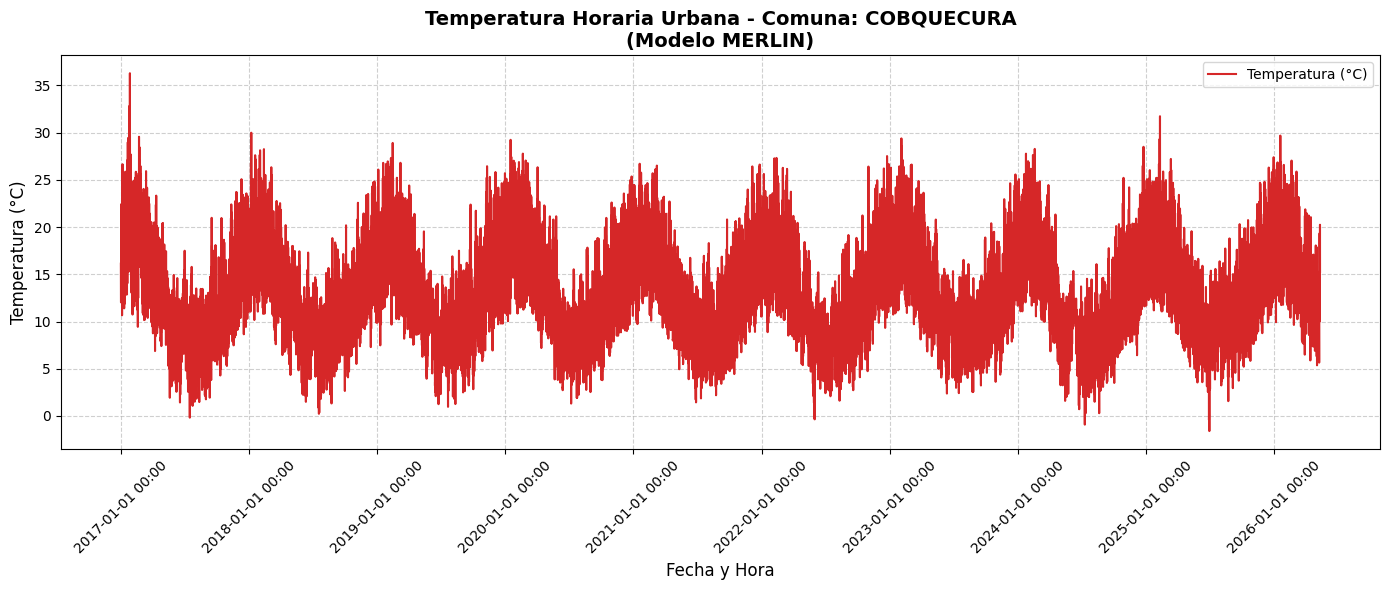

In [7]:
for comuna in listado_comunas: 

    # 3. Filtrar por la comuna deseada
    df_comuna = df_faltantes[df_faltantes['comuna'] == comuna]
    
    if df_comuna.empty:
        print(f"[!] No se encontraron datos para la comuna: {comuna}")
        pass
        

    # 5. Configurar y dibujar el gráfico
    plt.figure(figsize=(14, 6))
    
    # Graficar la línea
    plt.plot(df_comuna['fecha_hora'], df_comuna['temperatura'], 
             color='#d62728', linewidth=1.5, label='Temperatura (°C)')
    
    # Formateo visual
    plt.title(f'Temperatura Horaria Urbana - Comuna: {comuna}\n(Modelo MERLIN)', fontsize=14, fontweight='bold')
    plt.xlabel('Fecha y Hora', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    
    # Mejorar la visualización del eje X (Fechas)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout() # Ajusta los márgenes para que no se corten las etiquetas
    
    # Mostrar el gráfico en pantalla
    plt.show()

In [9]:
# Trabajar con ciclos de promedios diarios
df_r = df_faltantes.copy()
df_r["fecha_hora"] = pd.to_datetime(df_r["fecha_hora"])
df_r.set_index("fecha_hora", inplace=True)

# Se hará un resampleo
df_daily = df_r.groupby("comuna")["temperatura"].resample("D").mean().reset_index()

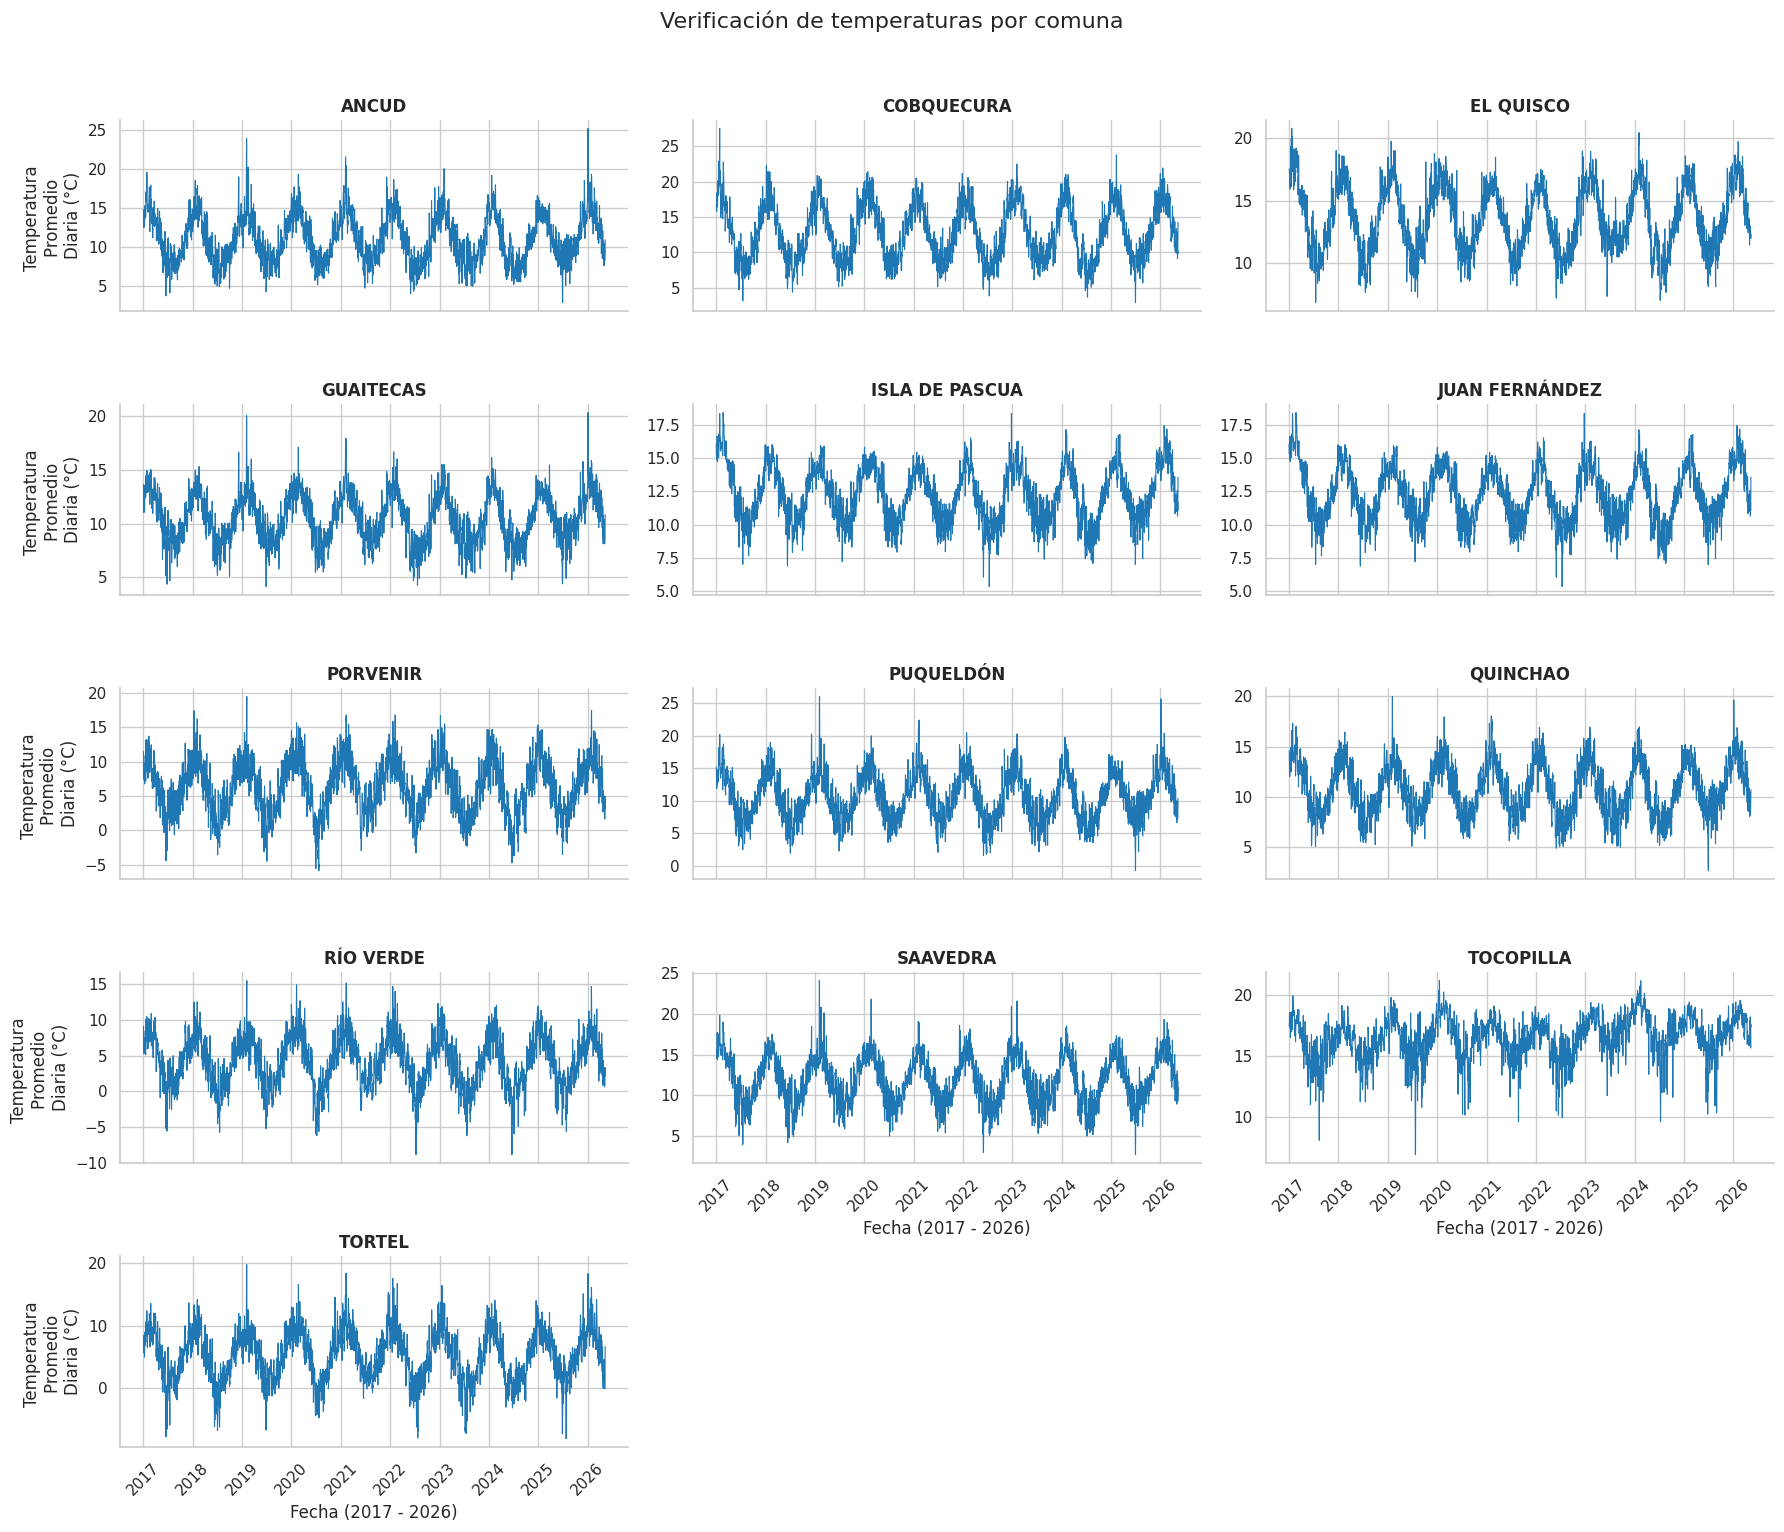

In [12]:
# Crear gráfico
sns.set_theme(style="whitegrid")

# 7. Crear una grilla de subgráficos (FacetGrid)
g = sns.FacetGrid(
    df_daily, 
    col="comuna", 
    col_wrap=3,      # Mostrar 3 gráficos por fila
    height=3,        # Altura de cada subgráfico
    aspect=2,        # Proporción (más ancho que alto)
    sharey=False     # False permite que cada comuna tenga su propia escala Y si los climas difieren mucho
)

# Mapear un gráfico de líneas a cada comuna
g.map(sns.lineplot, "fecha_hora", "temperatura", linewidth=0.8, color="tab:blue")

# Ajustes estéticos finales
g.set_axis_labels("Fecha (2017 - 2026)", "Temperatura \nPromedio \nDiaria (°C)")
g.set_titles(col_template="{col_name}", size=12, fontweight='bold')
g.fig.suptitle("Verificación de temperaturas por comuna", y=1.02, fontsize=16)

# Rotar las fechas para que se lean bien
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.savefig("../data/interim/temperaturas_faltantes.png", transparent=True, dpi=600)
plt.show()